# System Capacity & Care Load Analytics
## for Unaccompanied Children (UAC)
### U.S. Department of Health and Human Services
#### Unified Mentor Internship Project | Data Analytics Track
---
**Analysis Period:** January 2023 - December 2025
**Report Date:** April 2026

## Background & Context
The Unaccompanied Alien Children (UAC) Program is a federally mandated
initiative under which children apprehended by U.S. Customs and Border
Protection (CBP) are transferred to the Department of Health and Human
Services (HHS) for medical screening, quarantine, sheltering, and
eventual placement with vetted sponsors.

**Care Pipeline:**
- Intake into CBP custody
- Transfer to HHS care facilities
- Medical, psychological, and welfare support
- Discharge and reunification with sponsors

## Problem Statement
Although daily operational data is collected, HHS currently lacks a
centralized analytical framework to continuously assess:

- Total care system load
- Balance between inflow and outflow
- Capacity stress and relief periods
- Sustainability of care delivery over time

Without structured analytics, decision-making becomes reactive,
increasing the risk of overcrowding, delayed care, and strain on
healthcare infrastructure.

## Objectives

### Primary Objectives
- Quantify daily and cumulative care load across CBP and HHS
- Identify periods of capacity strain and relief
- Analyze balance between intake, transfers, and discharges

### Secondary Objectives
- Support healthcare staffing and shelter planning
- Improve situational awareness for policymakers
- Enable data-driven humanitarian response evaluation

## Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| Date | Datetime | Daily reporting date |
| Children Apprehended (CBP) | Flow | Daily new intake |
| Children in CBP Custody | Stock | Active CBP care load |
| Children Transferred out of CBP | Flow | Daily transfers to HHS |
| Children in HHS Care | Stock | Active HHS care load |
| Children Discharged from HHS | Flow | Successful sponsor placements |



## Notebook Structure

| Section | Description |
|---------|-------------|
| Section 1 | Data Ingestion & Structuring |
| Section 2 | Data Quality & Validation |
| Section 3 | Derived Healthcare Capacity Metrics |
| Section 4 | Trend & Temporal Analysis |
| Section 5 | Pressure & Stress Identification |
| Section 6 | Key Performance Indicators (KPIs) |
| Section 7 | EDA Visualizations |
| Section 8 | Forecasting |

#Install Required Libraires

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Ingestion & Structuring

##load the CSV file

In [2]:
df = pd.read_csv('/content/HHS_Unaccompanied_Alien_Children_Program.csv')
df.head(3)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [4]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


###Convert Date

In [5]:
df['Date'] = df['Date'].astype('datetime64[us]')

###Chronological ordering

In [6]:
df = df.sort_values(by='Date').reset_index(drop=True)

###Handle Missing values

In [7]:
df.isnull().sum()

,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


<p>almost 450 rows are null</p>

In [8]:
df[df.isnull().any(axis = 1)]

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
720,NaT,NaN,NaN,NaN,NaN,NaN
721,NaT,NaN,NaN,NaN,NaN,NaN
722,NaT,NaN,NaN,NaN,NaN,NaN
723,NaT,NaN,NaN,NaN,NaN,NaN
724,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1165,NaT,NaN,NaN,NaN,NaN,NaN
1166,NaT,NaN,NaN,NaN,NaN,NaN
1167,NaT,NaN,NaN,NaN,NaN,NaN
1168,NaT,NaN,NaN,NaN,NaN,NaN


In [9]:
df.iloc[719]

,719
Date,2025-12-21 00:00:00
Children apprehended and placed in CBP custody*,6.0
Children in CBP custody,18.0
Children transferred out of CBP custody,11.0
Children in HHS Care,"2,484"
Children discharged from HHS Care,14.0


###max date is 21-12-2025 and remaining records are null so removing those null records

In [10]:
# droping the null records
df = df.dropna()

In [11]:
df.isnull().sum()

,0
Date,0
Children apprehended and placed in CBP custody*,0
Children in CBP custody,0
Children transferred out of CBP custody,0
Children in HHS Care,0
Children discharged from HHS Care,0


###missing dates from selected date range

In [12]:
# get the all dates using range min date to max date
expected_days = pd.date_range(start=df['Date'].min(),end=df['Date'].max(),freq='D')

# find the missing dates
missing_dates = expected_days.difference(df['Date'])

missing_dates

DatetimeIndex(['2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-26',
               ...
               '2025-11-22', '2025-11-26', '2025-11-28', '2025-11-29',
               '2025-12-05', '2025-12-06', '2025-12-12', '2025-12-13',
               '2025-12-19', '2025-12-20'],
              dtype='datetime64[ns]', length=355, freq=None)

In [13]:
expected_days

DatetimeIndex(['2023-01-12', '2023-01-13', '2023-01-14', '2023-01-15',
               '2023-01-16', '2023-01-17', '2023-01-18', '2023-01-19',
               '2023-01-20', '2023-01-21',
               ...
               '2025-12-12', '2025-12-13', '2025-12-14', '2025-12-15',
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-20', '2025-12-21'],
              dtype='datetime64[ns]', length=1075, freq='D')

In [14]:
print(len(df))
print(len(missing_dates))

720
355


###fill missing dates using forwardfill

In [15]:
df = df.set_index('Date')
df = df.reindex(expected_days)
df = df.ffill()
df = df.reset_index()
df = df.rename(columns={'index': 'Date'})

In [16]:
len(df)

1075

###creating a new column that defines that this column is original or imputed

In [17]:
df['data_status'] = df['Date'].isin(missing_dates).map({True: 'Imputed', False: 'Original'})

# Fixing flow columns for imputed rows
flow_columns = [
    'Children apprehended and placed in CBP custody*',
    'Children transferred out of CBP custody',
    'Children discharged from HHS Care'
]
df.loc[df['data_status'] == 'Imputed', flow_columns] = 0

df.head(5)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,data_status
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0,Original
1,2023-01-13,0.0,53.0,0.0,"6,566",0.0,Imputed
2,2023-01-14,0.0,53.0,0.0,"6,566",0.0,Imputed
3,2023-01-15,0.0,53.0,0.0,"6,566",0.0,Imputed
4,2023-01-16,0.0,53.0,0.0,"6,566",0.0,Imputed


# Data Quality & Validation

In [18]:
# removing comma from values in children in HHS care
df['Children in HHS Care'] = df['Children in HHS Care'].str.replace(",","")

###data type conversion

In [19]:
columns = df.drop(columns=['Date','data_status'],axis = 1).columns
df[columns] = df[columns].astype('int64')

###check duplicates

In [20]:
df.duplicated().sum()

np.int64(0)

no duplicates

###Validate logical constraints:
- Transfers ≤ CBP custody
- Discharges ≤ HHS care


In [21]:
df['CBP Transfer Violation'] = df['Children transferred out of CBP custody'] > df['Children in CBP custody']

In [22]:
df['HHS Discharge Violation'] = df['Children discharged from HHS Care'] > df['Children in HHS Care']

In [23]:
df['Anomaly Flag'] = df['CBP Transfer Violation'] | df['HHS Discharge Violation']

In [24]:
print(f"CBP Transfer Violations: {df['CBP Transfer Violation'].sum()}")
print(f"HHS Discharge Violations: {df['HHS Discharge Violation'].sum()}")
print(f"Total Anomaly Rows: {df['Anomaly Flag'].sum()}")

CBP Transfer Violations: 86
HHS Discharge Violations: 0
Total Anomaly Rows: 86


###Anomaly flagging

In [25]:
# flagged rows
df[df['Anomaly Flag'] == True][['Date',
'Children in CBP custody',
'Children transferred out of CBP custody',
'CBP Transfer Violation',
'HHS Discharge Violation']]

,Date,Children in CBP custody,Children transferred out of CBP custody,CBP Transfer Violation,HHS Discharge Violation
12,2023-01-24,42,47,True,False
13,2023-01-25,22,41,True,False
21,2023-02-02,13,23,True,False
41,2023-02-22,215,230,True,False
42,2023-02-23,162,178,True,False
...,...,...,...,...,...
749,2025-01-30,42,47,True,False
752,2025-02-02,22,41,True,False
759,2025-02-09,13,23,True,False
763,2025-02-13,10,23,True,False


# Derived Metrics

###Total System Load

In [26]:
# total system load
df['Total System Load'] = df['Children in CBP custody'] + df['Children in HHS Care']

###Net Daily Intake

In [27]:
# net daily intake
df['Net Daily Intake'] = df['Children transferred out of CBP custody'] - df['Children discharged from HHS Care']

###Discharge Offset Ratio

In [28]:
# shows how effectively HHS is clearing incoming cases
df['Discharge Offset Ratio'] = df['Children discharged from HHS Care'] / df['Children transferred out of CBP custody']

###Care Load Growth Rate

In [29]:
# care load growth rate
df['Care Load Growth Rate'] = df['Total System Load'].pct_change() * 100

###Backlog Indicator

In [30]:
# backlog indicatror
df['Backlog Indicator'] = df['Net Daily Intake'].cumsum()

In [31]:
df.head(5)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,data_status,CBP Transfer Violation,HHS Discharge Violation,Anomaly Flag,Total System Load,Net Daily Intake,Discharge Offset Ratio,Care Load Growth Rate,Backlog Indicator
0,2023-01-12,33,53,34,6566,436,Original,False,False,False,6619,-402,12.823529,NaN,-402
1,2023-01-13,0,53,0,6566,0,Imputed,False,False,False,6619,0,NaN,0.0,-402
2,2023-01-14,0,53,0,6566,0,Imputed,False,False,False,6619,0,NaN,0.0,-402
3,2023-01-15,0,53,0,6566,0,Imputed,False,False,False,6619,0,NaN,0.0,-402
4,2023-01-16,0,53,0,6566,0,Imputed,False,False,False,6619,0,NaN,0.0,-402


# Trend & Temporal Analysis

###Daily/Weekly/Monthly trends

In [32]:
#  Daily, weekly, and monthly care load trends
df_weekly = df.resample('W', on='Date')['Total System Load'].mean().reset_index()
df_monthly = df.resample('ME', on='Date')['Total System Load'].mean().reset_index()

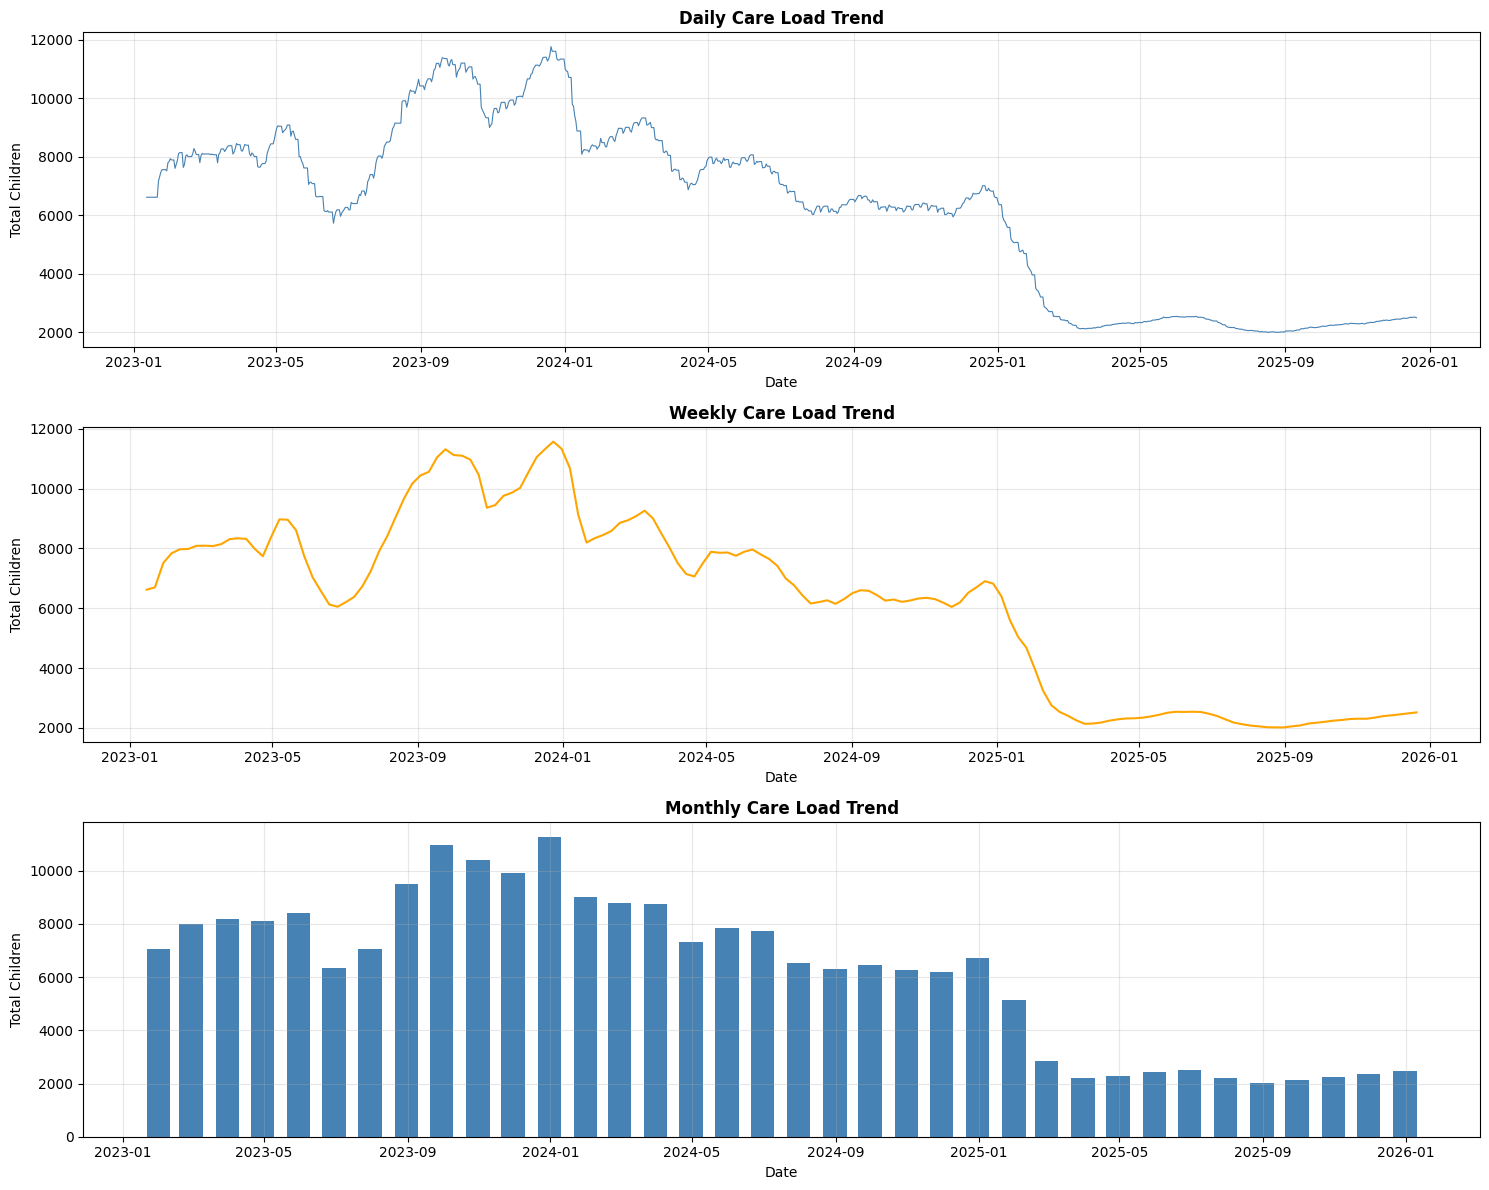

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Daily
axes[0].plot(df['Date'], df['Total System Load'],
             color='steelblue', linewidth=0.8)
axes[0].set_title('Daily Care Load Trend', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Children')
axes[0].grid(True, alpha=0.3)

# Weekly
axes[1].plot(df_weekly['Date'], df_weekly['Total System Load'],
             color='orange', linewidth=1.5)
axes[1].set_title('Weekly Care Load Trend', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Children')
axes[1].grid(True, alpha=0.3)

# Monthly
axes[2].bar(df_monthly['Date'], df_monthly['Total System Load'],
            color='steelblue', width=20)
axes[2].set_title('Monthly Care Load Trend', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Total Children')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###High load periods

In [34]:
#  Identification of Sustained High Load Periods
threshold = df['Total System Load'].quantile(0.80)

# falg high load days
df['High Load Period'] = df['Total System Load'] > threshold

# consicutive high load days
df['High Load Streak'] = (df['High Load Period'] != df['High Load Period'].shift()).cumsum()

sustained = df[df['High Load Period'] == True].groupby('High Load Streak')['Date'].count()
print(sustained)

High Load Streak
2     17
4    161
6      3
8     34
Name: Date, dtype: int64


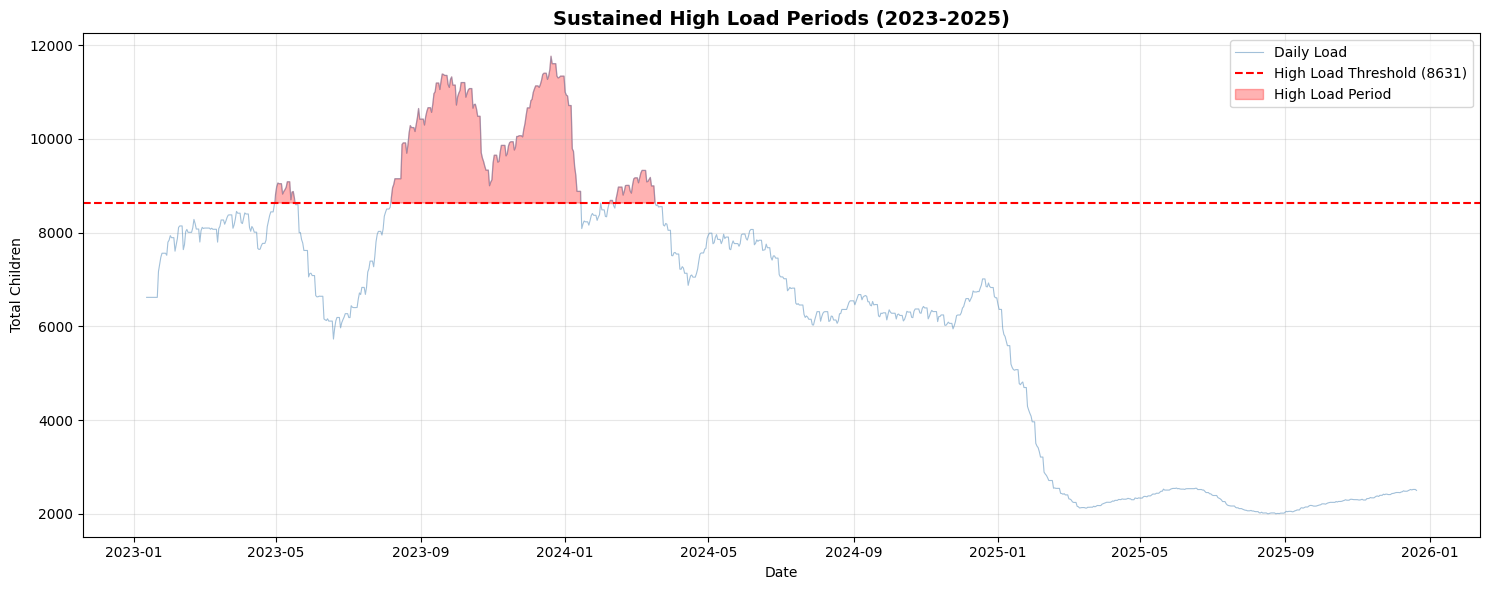

In [35]:
fig, ax = plt.subplots(figsize=(15, 6))

# Total system load line
ax.plot(df['Date'], df['Total System Load'],
        color='steelblue', linewidth=0.8,
        alpha=0.5, label='Daily Load')

# Threshold line
threshold = df['Total System Load'].quantile(0.80)
ax.axhline(y=threshold, color='red',
           linestyle='--', linewidth=1.5,
           label=f'High Load Threshold ({threshold:.0f})')

# Shade high load periods
ax.fill_between(df['Date'], df['Total System Load'], threshold,
                where=df['Total System Load'] > threshold,
                alpha=0.3, color='red', label='High Load Period')

ax.set_title('Sustained High Load Periods (2023-2025)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Children')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Early vs Late comparison

In [36]:
# Early vs Late Timeline Comparison
early = df[df['Date'] < '2024-01-01']
mid   = df[(df['Date'] >= '2024-01-01') &
           (df['Date'] < '2025-01-01')]
late  = df[df['Date'] >= '2025-01-01']

# Compare
print(f"2023 Avg Load: {early['Total System Load'].mean():.0f}")
print(f"2024 Avg Load: {mid['Total System Load'].mean():.0f}")
print(f"2025 Avg Load: {late['Total System Load'].mean():.0f}")

2023 Avg Load: 8825
2024 Avg Load: 7324
2025 Avg Load: 2577


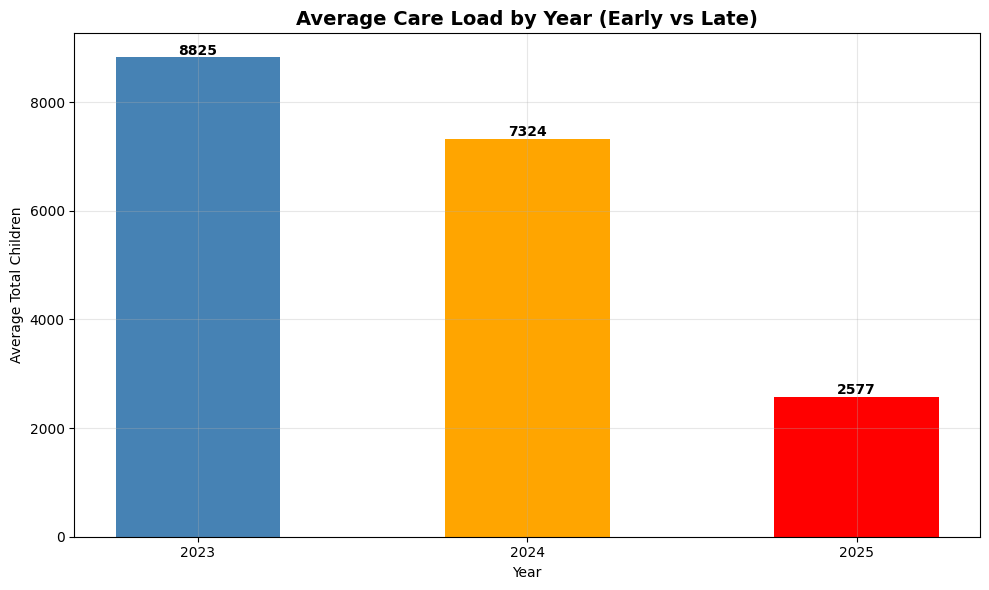

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

# Average load per year
yearly_avg = df.groupby(df['Date'].dt.year)['Total System Load'].mean()

bars = ax.bar(yearly_avg.index.astype(str),
              yearly_avg.values,
              color=['steelblue', 'orange', 'red'],
              width=0.5)

# Add value labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{bar.get_height():.0f}',
            ha='center', fontweight='bold')

ax.set_title('Average Care Load by Year (Early vs Late)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Average Total Children')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Peak (max) and minimum load per year
yearly_load_stats = df.groupby(df['Date'].dt.year)['Total System Load'].agg(
    Peak_Load='max',
    Min_Load='min'
).reset_index()

print(yearly_load_stats)

   Date  Peak_Load  Min_Load
0  2023      11762      5730
1  2024      10994      5947
2  2025       6471      2002


# Pressure & Stress Identification

###Rolling averages

In [39]:
# Rolling averages (7-day, 14-day)
df['7day Rolling Avg'] = df['Total System Load'].rolling(7).mean()
df['14day Rolling Avg'] = df['Total System Load'].rolling(14).mean()

###Variability analysis

In [40]:
# Variability analysis
df_monthly_std = df.resample('ME', on='Date')['Total System Load'].std().reset_index()
df_monthly_mean = df.resample('ME', on='Date')['Total System Load'].mean().reset_index()

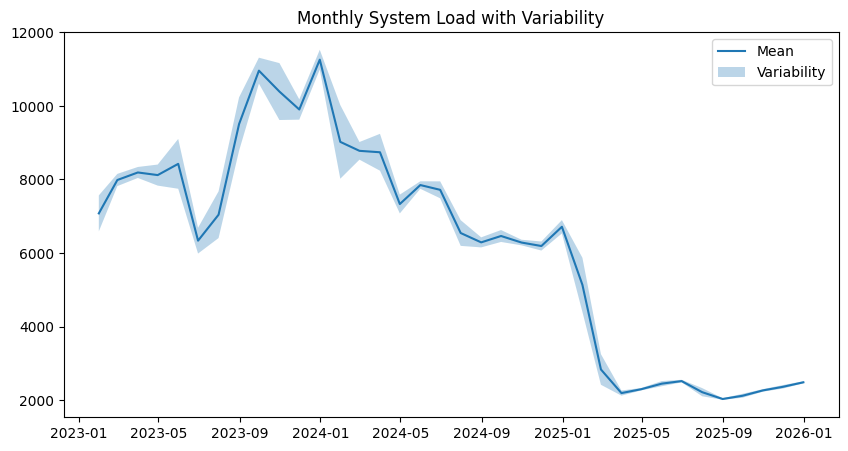

In [41]:
plt.figure(figsize=(10,5))

plt.plot(df_monthly_mean['Date'], df_monthly_mean['Total System Load'], label='Mean')
plt.fill_between(
    df_monthly_mean['Date'],
    df_monthly_mean['Total System Load'] - df_monthly_std['Total System Load'],
    df_monthly_mean['Total System Load'] + df_monthly_std['Total System Load'],
    alpha=0.3,
    label='Variability'
)

plt.legend()
plt.title('Monthly System Load with Variability')
plt.show()

###Strain windows

In [42]:
# Detection of prolonged strain windows
strain_threshold = df['7day Rolling Avg'].quantile(0.90)
df['Strain Window'] = df['7day Rolling Avg'] > strain_threshold

# KPI

###Total Children Under Care

In [43]:
total_children = df['Total System Load'].mean()

###Net Intake Pressure

In [44]:
net_intake_pressure = df['Net Daily Intake'].mean()

###Care Load Volatility Index

In [45]:
volatility_index = df['Total System Load'].std()

###Backlog Accumulation Rate

In [46]:
backlog_rate = df['Backlog Indicator'].iloc[-1]

###Discharge Offset Ratio (overall)

In [47]:
discharge_offset = (df['Children discharged from HHS Care'].sum() /
                   df['Children transferred out of CBP custody'].sum())

In [57]:
print(f"{'Average Daily Children Under Care':<40} {total_children:>10.0f}")
print(f"{'Net Intake Pressure':<40} {net_intake_pressure:>10.2f}")
print(f"{'Care Load Volatility Index':<40} {volatility_index:>10.2f}")
print(f"{'Backlog Accumulation Rate':<40} {backlog_rate:>10.0f}")
print(f"{'Discharge Offset Ratio':<40} {discharge_offset:>10.2f}")

Average Daily Children Under Care              6251
Net Intake Pressure                          -29.96
Care Load Volatility Index                  2922.85
Backlog Accumulation Rate                    -32212
Discharge Offset Ratio                         1.35


#EDA Visualization

In [49]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates
# Set style
plt.style.use('seaborn-v0_8')
colors = ['steelblue', 'orange', 'red', 'green', 'purple']

### System Overview Charts:

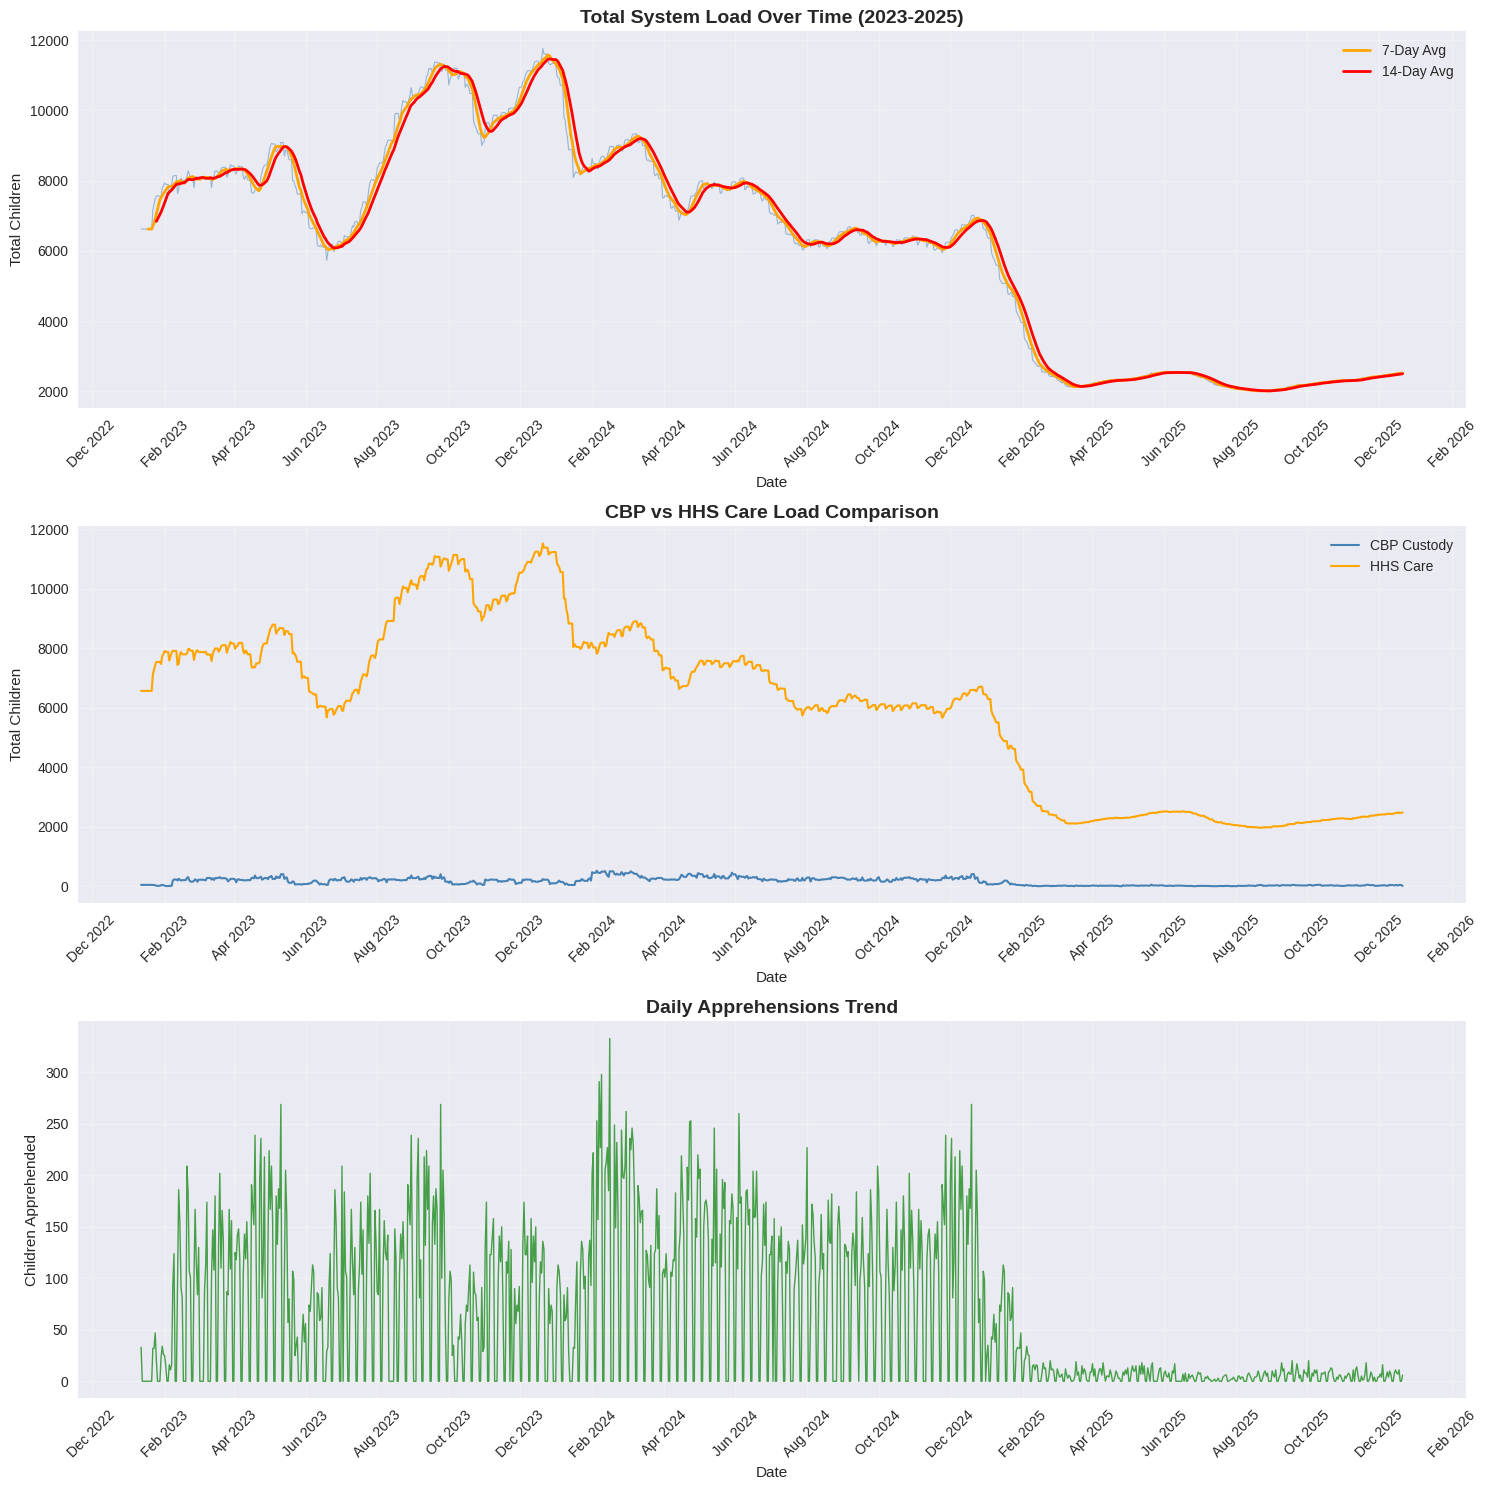

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# Total System Load
axes[0].plot(df['Date'], df['Total System Load'],
             color='steelblue', linewidth=0.8, alpha=0.5)
axes[0].plot(df['Date'], df['7day Rolling Avg'],
             color='orange', linewidth=2, label='7-Day Avg')
axes[0].plot(df['Date'], df['14day Rolling Avg'],
             color='red', linewidth=2, label='14-Day Avg')
axes[0].set_title('Total System Load Over Time (2023-2025)',
                  fontweight='bold', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Children')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# CBP vs HHS Comparison
axes[1].plot(df['Date'], df['Children in CBP custody'],
             color='steelblue', linewidth=1.5, label='CBP Custody')
axes[1].plot(df['Date'], df['Children in HHS Care'],
             color='orange', linewidth=1.5, label='HHS Care')
axes[1].set_title('CBP vs HHS Care Load Comparison',
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Children')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# Daily Apprehensions
axes[2].plot(df['Date'],
             df['Children apprehended and placed in CBP custody*'],
             color='green', linewidth=1, alpha=0.7)
axes[2].set_title('Daily Apprehensions Trend',
                  fontweight='bold', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Children Apprehended')
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

###Flow Analysis Charts:

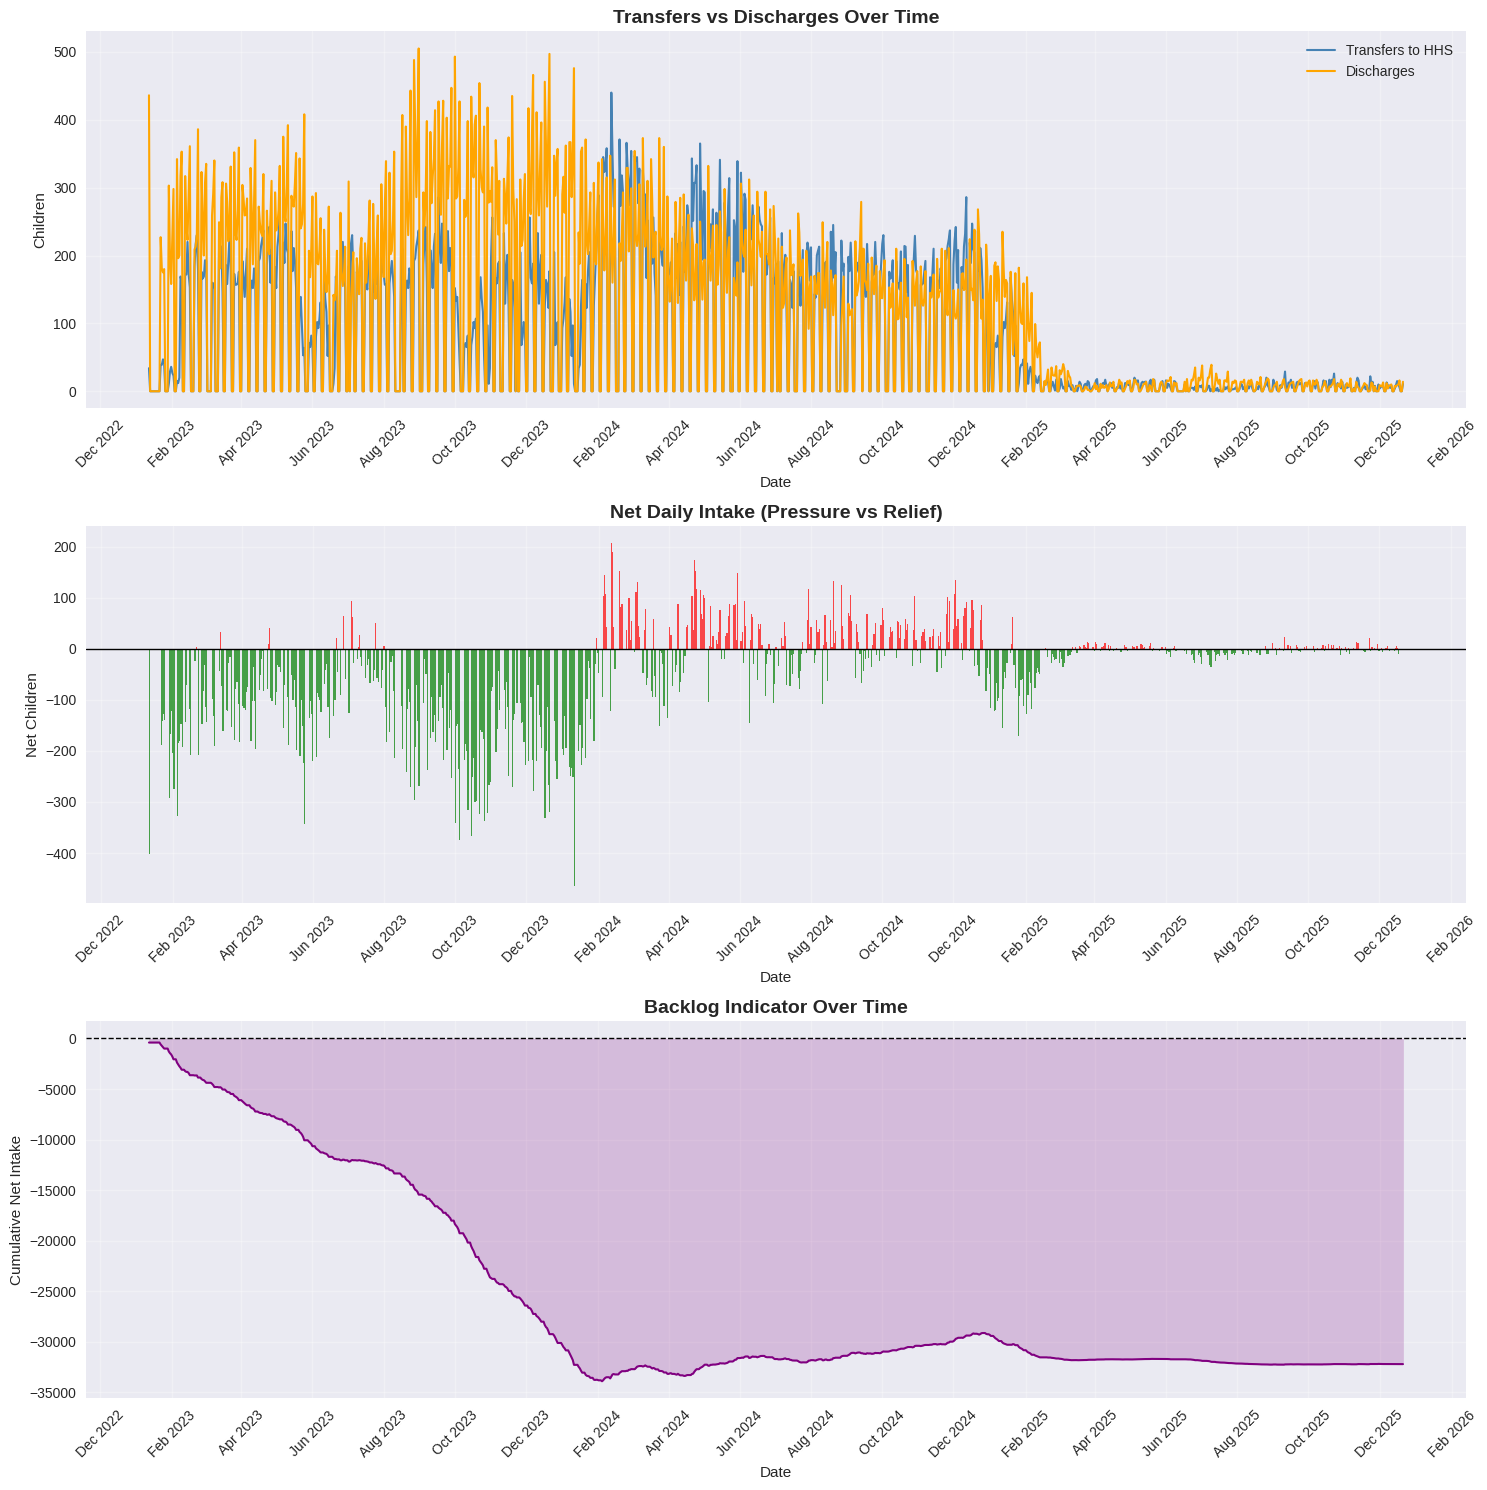

In [51]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# Transfers vs Discharges
axes[0].plot(df['Date'],
             df['Children transferred out of CBP custody'],
             color='steelblue', linewidth=1.5, label='Transfers to HHS')
axes[0].plot(df['Date'],
             df['Children discharged from HHS Care'],
             color='orange', linewidth=1.5, label='Discharges')
axes[0].set_title('Transfers vs Discharges Over Time',
                  fontweight='bold', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Children')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Net Daily Intake
axes[1].bar(df['Date'], df['Net Daily Intake'],
            color=df['Net Daily Intake'].apply(
                lambda x: 'red' if x > 0 else 'green'),
            alpha=0.7, width=1)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Net Daily Intake (Pressure vs Relief)',
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Net Children')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# Backlog Indicator
axes[2].plot(df['Date'], df['Backlog Indicator'],
             color='purple', linewidth=1.5)
axes[2].fill_between(df['Date'], df['Backlog Indicator'],
                     alpha=0.2, color='purple')
axes[2].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Backlog Indicator Over Time',
                  fontweight='bold', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Cumulative Net Intake')
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Anomaly Charts:

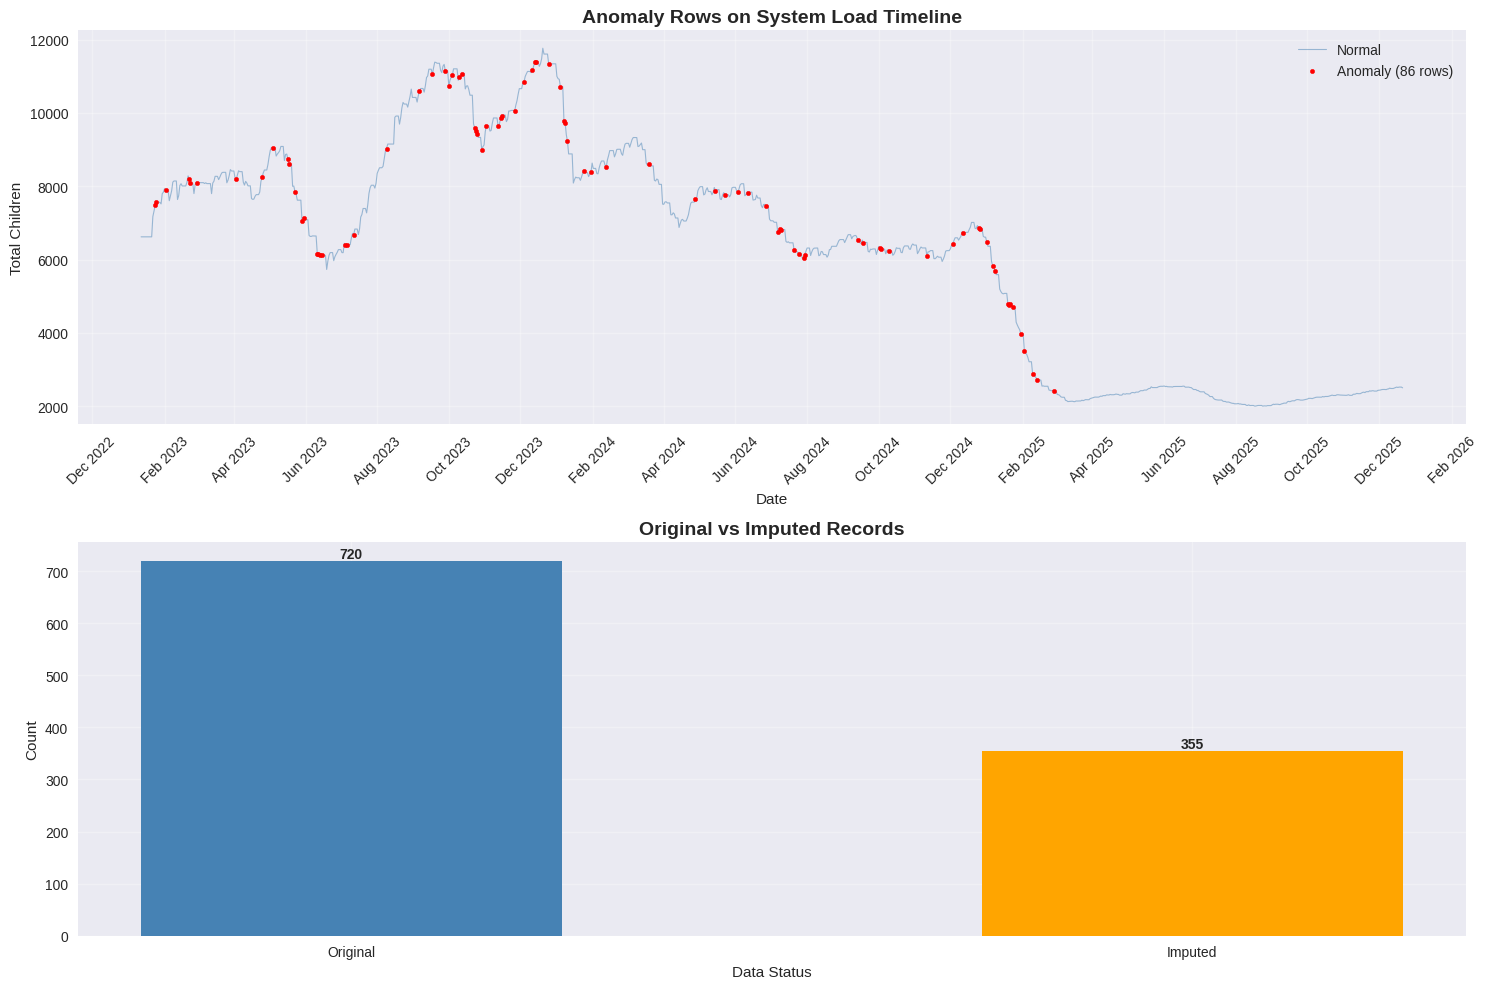

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Anomaly rows highlighted
axes[0].plot(df['Date'], df['Total System Load'],
             color='steelblue', linewidth=0.8,
             alpha=0.5, label='Normal')
axes[0].scatter(df[df['Anomaly Flag'] == True]['Date'],
                df[df['Anomaly Flag'] == True]['Total System Load'],
                color='red', s=10,
                label=f'Anomaly ({df["Anomaly Flag"].sum()} rows)',
                zorder=5)
axes[0].set_title('Anomaly Rows on System Load Timeline',
                  fontweight='bold', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Children')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Data Status
status_counts = df['data_status'].value_counts()
axes[1].bar(status_counts.index, status_counts.values,
            color=['steelblue', 'orange'], width=0.5)
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 5, str(v),
                 ha='center', fontweight='bold')
axes[1].set_title('Original vs Imputed Records',
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Data Status')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### KPI Summary Charts:

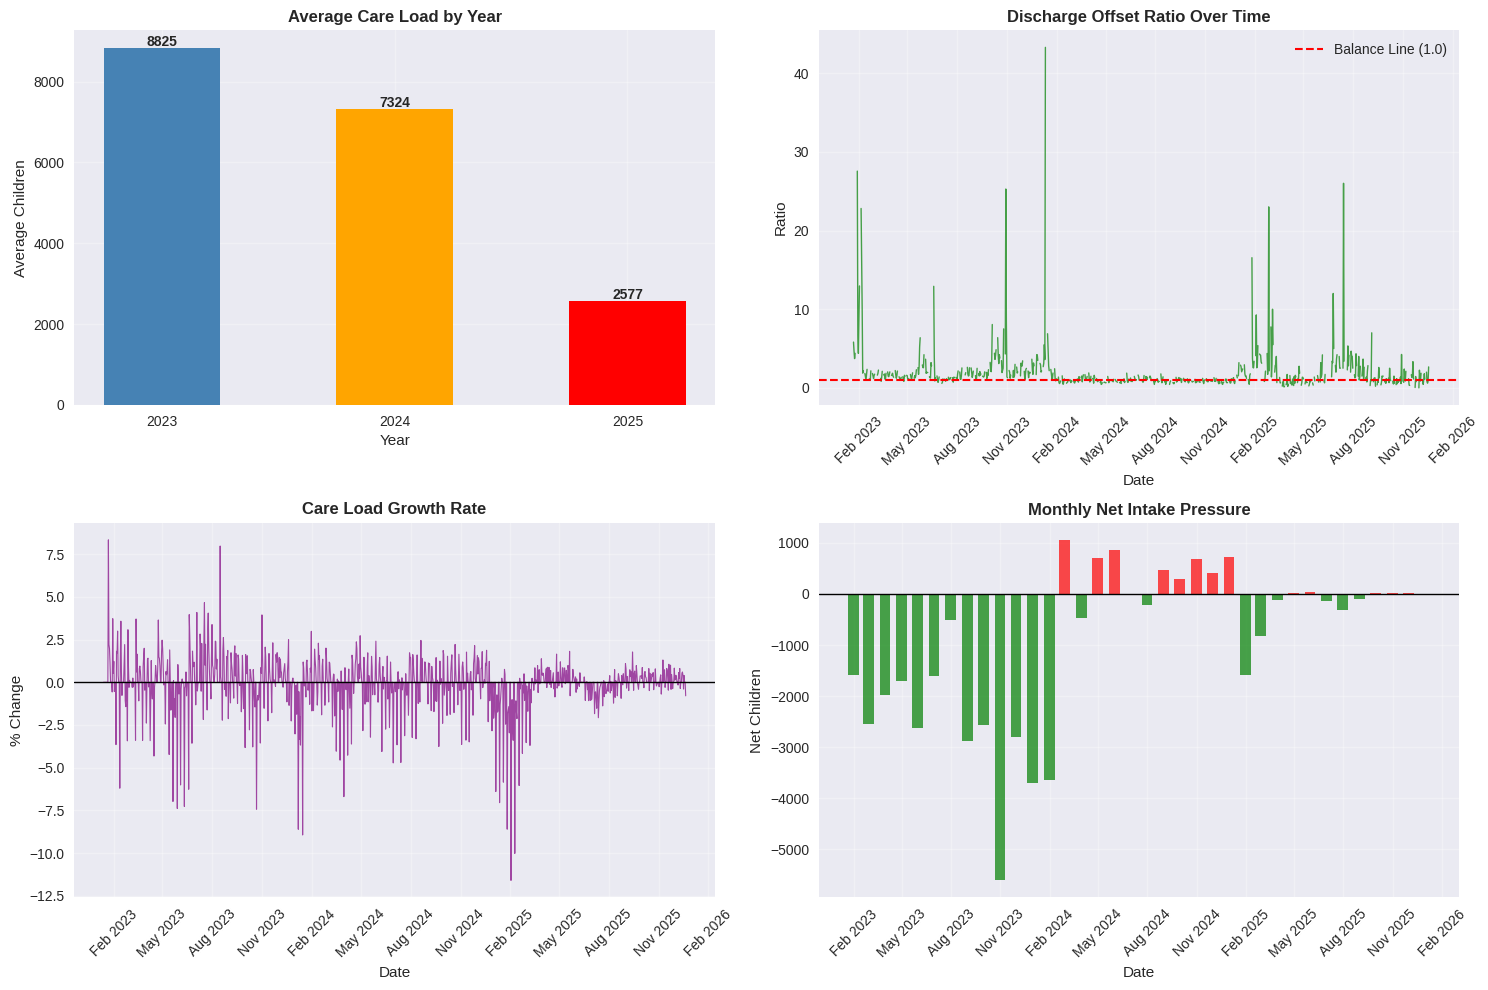

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Yearly Average Load
yearly_avg = df.groupby(df['Date'].dt.year)['Total System Load'].mean()
bars = axes[0,0].bar(yearly_avg.index.astype(str),
                     yearly_avg.values,
                     color=['steelblue', 'orange', 'red'],
                     width=0.5)
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   f'{bar.get_height():.0f}',
                   ha='center', fontweight='bold')
axes[0,0].set_title('Average Care Load by Year',
                    fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Average Children')
axes[0,0].grid(True, alpha=0.3)

# Discharge Offset Ratio
axes[0,1].plot(df['Date'], df['Discharge Offset Ratio'],
               color='green', linewidth=1, alpha=0.7)
axes[0,1].axhline(y=1, color='red', linestyle='--',
                  linewidth=1.5, label='Balance Line (1.0)')
axes[0,1].set_title('Discharge Offset Ratio Over Time',
                    fontweight='bold')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Ratio')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=45)

# Care Load Growth Rate
axes[1,0].plot(df['Date'], df['Care Load Growth Rate'],
               color='purple', linewidth=0.8, alpha=0.7)
axes[1,0].axhline(y=0, color='black', linewidth=1)
axes[1,0].set_title('Care Load Growth Rate',
                    fontweight='bold')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('% Change')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)

# Monthly Net Intake
monthly_intake = df.resample('ME', on='Date')['Net Daily Intake'].sum().reset_index()
axes[1,1].bar(monthly_intake['Date'],
              monthly_intake['Net Daily Intake'],
              color=monthly_intake['Net Daily Intake'].apply(
                  lambda x: 'red' if x > 0 else 'green'),
              width=20, alpha=0.7)
axes[1,1].axhline(y=0, color='black', linewidth=1)
axes[1,1].set_title('Monthly Net Intake Pressure',
                    fontweight='bold')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Net Children')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

###Pressure & Stress Charts:

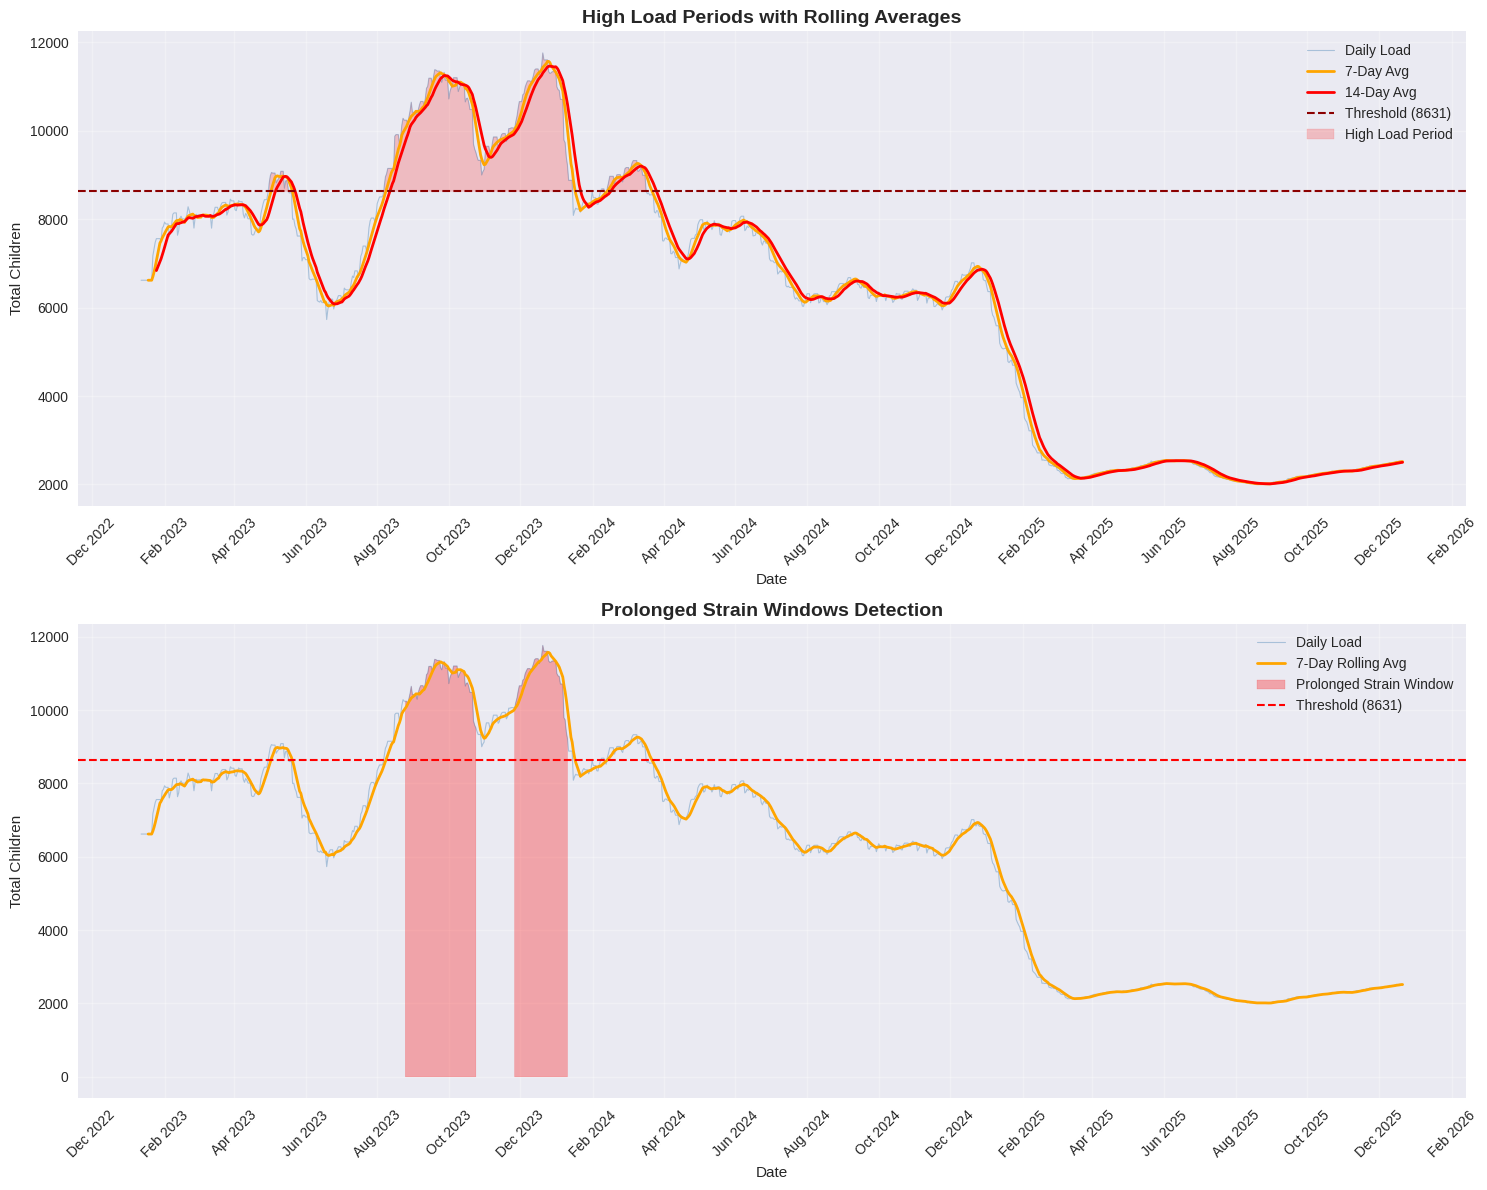

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# High Load Periods
threshold = df['Total System Load'].quantile(0.80)
axes[0].plot(df['Date'], df['Total System Load'],
             color='steelblue', linewidth=0.8,
             alpha=0.4, label='Daily Load')
axes[0].plot(df['Date'], df['7day Rolling Avg'],
             color='orange', linewidth=2, label='7-Day Avg')
axes[0].plot(df['Date'], df['14day Rolling Avg'],
             color='red', linewidth=2, label='14-Day Avg')
axes[0].axhline(y=threshold, color='darkred',
                linestyle='--', linewidth=1.5,
                label=f'Threshold ({threshold:.0f})')
axes[0].fill_between(df['Date'], df['Total System Load'],
                     threshold,
                     where=df['Total System Load'] > threshold,
                     alpha=0.2, color='red',
                     label='High Load Period')
axes[0].set_title('High Load Periods with Rolling Averages',
                  fontweight='bold', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Children')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Strain Windows
axes[1].plot(df['Date'], df['Total System Load'],
             color='steelblue', linewidth=0.8,
             alpha=0.4, label='Daily Load')
axes[1].plot(df['Date'], df['7day Rolling Avg'],
             color='orange', linewidth=2,
             label='7-Day Rolling Avg')
axes[1].fill_between(df['Date'], 0,
                     df['Total System Load'],
                     where=df['Strain Window'] == True,
                     alpha=0.3, color='red',
                     label='Prolonged Strain Window')
axes[1].axhline(y=threshold, color='red',
                linestyle='--', linewidth=1.5,
                label=f'Threshold ({threshold:.0f})')
axes[1].set_title('Prolonged Strain Windows Detection',
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Children')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [55]:
cols = [
    # Original columns
    'Date',
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care',

    # Data quality columns
    'data_status',
    'CBP Transfer Violation',
    'HHS Discharge Violation',
    'Anomaly Flag',

    # Derived metrics
    'Total System Load',
    'Net Daily Intake',
    'Care Load Growth Rate',
    'Backlog Indicator',
    'Discharge Offset Ratio',

    # Trend columns
    'High Load Period',
    'High Load Streak',
    '7day Rolling Avg',
    '14day Rolling Avg',
    'Strain Window'
]

df = df[cols]
df.to_csv('uac_cleaned.csv', index=False)
print("Saved successfully!")

Saved successfully!
